# Model-Error Alpine Config Generator

Writes `model_error_config.json` files for Monte Carlo input-concentration error propagation (see `Utilities/model_error_runner.py`) — one per reaction system, saved under `Results/Model Error/<system>/`. Each config is submitted on Alpine with:

```bash
sbatch --cpus-per-task=32 "ODE Runner/run_model_error.sh" "Results/Model Error/<system>/model_error_config.json"
```

**Systems generated:**
- **EC FAS** — full *E. coli* FAS network (`Reactions/EC_FAS_ME1`)
- **Camelina Simple FAS** — Camelina FAS network at its baseline FabB concentration (`Reactions/Camelina_FAS_simple`)
- **Camelina Simple FAS 0.2x FabB** — same network, FabB at 0.2× baseline
- **Camelina Simple FAS 5x FabB** — same network, FabB at 5× baseline

Run every cell top to bottom to write the configs. No simulation happens here — this notebook only builds each reaction network (to catch species/parameter typos before submitting) and writes the JSON configs. The final section is meant to be run later, after each Alpine job has finished and been synced back — it plots every run's FA profile with error bars.

---
*Annette Thompson · Fox and Shirts Labs, CU Boulder · 2026 · Developed with assistance from Claude Code (Claude Sonnet 5)*

## Setup

In [46]:
import sys
sys.path.insert(0, "../")

from pathlib import Path
import json

import jax
jax.config.update('jax_enable_x64', True)

from Utilities.reaction_model_builder import build_ode_system_from_reactions

## Shared Settings

Monte Carlo settings shared by every config below (perturbation noise, sample count, solve window, step budget, and the reported observables). The only things that vary per system are the reaction network, initial conditions, scaling groups, and solver tolerance.

In [47]:
SIGMA_FRAC = 0.05   # 5% relative standard deviation on every perturbed species
N_SAMPLES = 300
SEED = 0
TIME_RANGE = [0.0, 720.0]   # seconds
MAX_STEPS = 10_000
OBSERVABLES = [{"type": "total_production"}, {"type": "mean_chain_length"}]


def write_model_error_config(
    *,
    system_name: str,
    reactions_path: str,
    y0: dict,
    perturb_species: list,
    scaling_groups: dict,
    tolerance: dict,
) -> Path:
    """Build and write one model_error_config.json to Results/Model Error/<system_name>/."""
    output_folder = f"Results/Model Error/{system_name}"

    config = {
        "path_base": "../../..",  # Results/Model Error/<system>/ -> ... -> Python Model home
        "reactions_path": reactions_path,
        "folder_name": system_name,
        "output_folder": output_folder,
        "y0": y0,
        "scaling_groups": scaling_groups,
        "time_range": TIME_RANGE,
        "max_steps": MAX_STEPS,
        "perturb": {"species": perturb_species, "sigma_frac": SIGMA_FRAC},
        "n_samples": N_SAMPLES,
        "seed": SEED,
        "parallel": {"mode": "process", "n_workers": None},
        "tolerance": tolerance,
        "fa_profile": {"save": True},
        "observable": OBSERVABLES,
    }

    config_dir = Path(f"../{output_folder}")
    config_dir.mkdir(parents=True, exist_ok=True)
    config_path = config_dir / "model_error_config.json"
    with open(config_path, "w") as f:
        json.dump(config, f, indent=4)

    print(f"Wrote {config_path}")
    print(f'  Submit on Alpine with: sbatch --cpus-per-task=32 "ODE Runner/run_model_error.sh" "{output_folder}/model_error_config.json"')
    return config_path

## EC FAS

Full network including the FabA unsaturation pathway. Uses the same rate-constant scaling-group overrides (`d1`/`d2` zeroed, everything else left at 1) as the deterministic single-run notebook.

In [48]:
EC_REACTIONS_PATH = Path('../Reactions/EC_FAS_ME1')

ec_network, ec_species, ec_params, ec_param_values, ec_scaling_groups = build_ode_system_from_reactions(EC_REACTIONS_PATH)
print(f'Loaded {len(ec_species)} species, {len(ec_params)} params for {EC_REACTIONS_PATH.name}.')

ec_y0 = {
    "C2_AcCoA": 500.0, "C3_MalCoA": 500.0, "ACP": 10.0, "NADPH": 1000.0, "NADH": 1000.0,
    "FabD": 1.0, "FabH": 1.0, "FabG": 1.0, "FabZ": 1.0, "FabI": 1.0,
    "TesA": 10.0, "FabF": 1.0, "FabB": 1.0, "FabA": 1.0,
}
assert set(ec_y0).issubset(ec_species), "EC y0 species not found in reaction network"

ec_perturb_species = [
    "C2_AcCoA", "C3_MalCoA", "ACP", "NADPH", "NADH",
    "FabD", "FabH", "FabG", "FabZ", "FabI", "TesA", "FabF", "FabA", "FabB",
]

ec_scaling_group_overrides = {
    "a1": 1, "a2": 1, "a3": 1,
    "b1": 1, "b2": 1, "b3": 1,
    "c1": 1, "c2": 1, "c3": 1, "c4": 1,
    "d1": 0, "d2": 0, "e": 1, "f": 1,
    "x1": 1, "x2": 1, "x3": 1, "x4": 1,
}

write_model_error_config(
    system_name="EC FAS",
    reactions_path=f"Reactions/{EC_REACTIONS_PATH.name}",
    y0=ec_y0,
    perturb_species=ec_perturb_species,
    scaling_groups=ec_scaling_group_overrides,
    tolerance={"rtol": 1e-5, "atol": 1e-8},
)

Loaded 320 species, 222 params for EC_FAS_ME1.
Wrote ../Results/Model Error/EC FAS/model_error_config.json
  Submit on Alpine with: sbatch --cpus-per-task=32 "ODE Runner/run_model_error.sh" "Results/Model Error/EC FAS/model_error_config.json"


PosixPath('../Results/Model Error/EC FAS/model_error_config.json')

## Camelina Simple FAS — Baseline + FabB Variants


In [49]:
CAMELINA_REACTIONS_PATH = Path('../Reactions/Camelina_FAS_simple')

cam_network, cam_species, cam_params, cam_param_values, cam_scaling_groups = build_ode_system_from_reactions(CAMELINA_REACTIONS_PATH)
print(f'Loaded {len(cam_species)} species, {len(cam_params)} params for {CAMELINA_REACTIONS_PATH.name}.')

FABB_BASE = 1.0  # uM

cam_y0_base = {
    "C2_AcCoA": 500.0, "C3_MalCoA": 500.0, "ACP": 1.0, "NADPH": 1000.0, "NADH": 1000.0,
    "FabD": 0.5, "FabH": 0.25, "FabG": 1.0, "FabZ": 1.0, "FabI": 1.0,
    "TesA": 0.1, "FabF": 0.1, "FabB": FABB_BASE,
}
assert set(cam_y0_base).issubset(cam_species), "Camelina y0 species not found in reaction network"

cam_perturb_species = [
    "ACP", "FabB", "FabD", "FabF", "FabG", "FabH", "FabI", "FabZ", "TesA",
    "C2_AcCoA", "C3_MalCoA", "NADPH", "NADH",
]

cam_scaling_group_overrides = {
    "a1": 1, "a2": 1, "a3": 1,
    "b1": 1, "b2": 1, "b3": 1,
    "c1": 1, "c2": 1, "c3": 1, "c4": 1,
    "d1": 0, "d2": 0, "e": 1,
    "x1": 1, "x2": 1, "x3": 1, "x4": 1,
}

Loaded 160 species, 152 params for Camelina_FAS_simple.


In [50]:
cam_fabb_variants = {
    "Camelina Simple FAS": 1.0 * FABB_BASE,
    "Camelina Simple FAS 0.2x FabB": 0.2 * FABB_BASE,
    "Camelina Simple FAS 5x FabB": 5.0 * FABB_BASE,
}

for system_name, fabb_val in cam_fabb_variants.items():
    y0_variant = {**cam_y0_base, "FabB": fabb_val}
    write_model_error_config(
        system_name=system_name,
        reactions_path=f"Reactions/{CAMELINA_REACTIONS_PATH.name}",
        y0=y0_variant,
        perturb_species=cam_perturb_species,
        scaling_groups=cam_scaling_group_overrides,
        tolerance={"rtol": 1e-3, "atol": 1e-6},
    )
    print(f"  (FabB = {fabb_val:.3g} uM)")

Wrote ../Results/Model Error/Camelina Simple FAS/model_error_config.json
  Submit on Alpine with: sbatch --cpus-per-task=32 "ODE Runner/run_model_error.sh" "Results/Model Error/Camelina Simple FAS/model_error_config.json"
  (FabB = 1 uM)
Wrote ../Results/Model Error/Camelina Simple FAS 0.2x FabB/model_error_config.json
  Submit on Alpine with: sbatch --cpus-per-task=32 "ODE Runner/run_model_error.sh" "Results/Model Error/Camelina Simple FAS 0.2x FabB/model_error_config.json"
  (FabB = 0.2 uM)
Wrote ../Results/Model Error/Camelina Simple FAS 5x FabB/model_error_config.json
  Submit on Alpine with: sbatch --cpus-per-task=32 "ODE Runner/run_model_error.sh" "Results/Model Error/Camelina Simple FAS 5x FabB/model_error_config.json"
  (FabB = 5 uM)


## FA Profile with Error Bars (Completed Ensembles)

Run this section once each Alpine job has completed and been synced back. Reads each run's
`fa_chain_profile_samples.csv` (written because `"fa_profile": {"save": true}` is set in every
config above) and plots mean ± SD saturated/unsaturated mole fraction at each chain length.
EC FAS is the only one of the four systems with the FabA unsaturation pathway, so it's the only
run plotted with an unsaturated stack — the three Camelina configs have no `FabA.yaml`, so their
unsaturated fraction is identically zero and only the saturated bars are shown.

In [51]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-poster')


def plot_fa_profile(folder_name: str, *, show_unsaturated: bool) -> None:
    """Plot mean +/- SD saturated (and, if present, unsaturated) FA mole fraction per chain
    length from a completed model-error ensemble's fa_chain_profile_samples.csv."""
    results_folder = Path(f"../Results/Model Error/{folder_name}")
    profile_df = pd.read_csv(results_folder / "fa_chain_profile_samples.csv")

    chain_pattern = re.compile(r"^C(\d+)_sat_frac$")
    chains = sorted(int(chain_pattern.match(c).group(1)) for c in profile_df.columns if chain_pattern.match(c))
    sat_cols = [f"C{c}_sat_frac" for c in chains]

    sat_mean = profile_df[sat_cols].mean().to_numpy()
    sat_std = profile_df[sat_cols].std(ddof=1).to_numpy()

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(chains))
    error_kw = dict(capsize=5, capthick=1.5, elinewidth=1.5)
    ax.bar(x, sat_mean, yerr=sat_std, color='gray', edgecolor='black', label='Saturated', error_kw=error_kw)

    if show_unsaturated:
        unsat_cols = [f"C{c}_unsat_frac" for c in chains]
        unsat_mean = profile_df[unsat_cols].mean().to_numpy()
        unsat_std = profile_df[unsat_cols].std(ddof=1).to_numpy()
        ax.bar(x, unsat_mean, bottom=sat_mean, yerr=unsat_std, color='gray', edgecolor='black',
               hatch='///', label='Unsaturated', error_kw=error_kw)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in chains])
    ax.set_xlabel('FA Chain Length')
    ax.set_ylabel('Mole Fraction')
    ax.set_title(f'{folder_name} Fatty Acid Profile (mean \u00b1 SD, n={len(profile_df)} draws)')
    ax.legend()
    fig.tight_layout()
    plt.show()

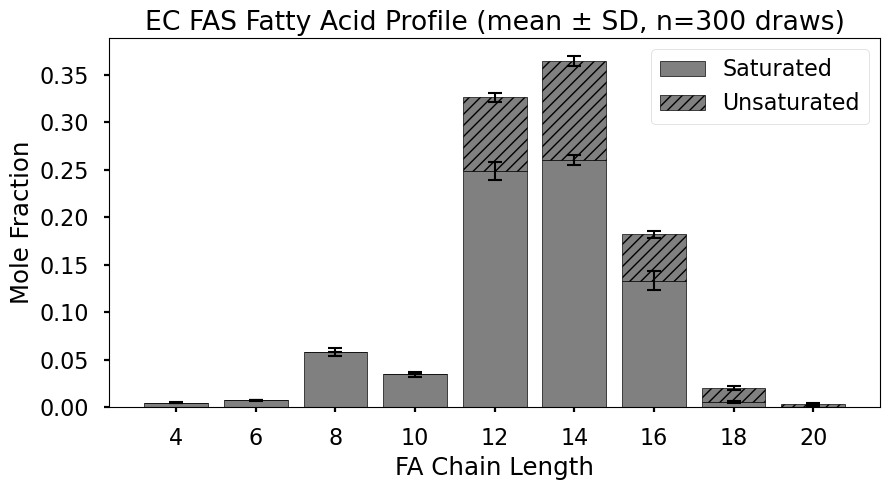

In [54]:
plot_fa_profile("EC FAS", show_unsaturated=True)

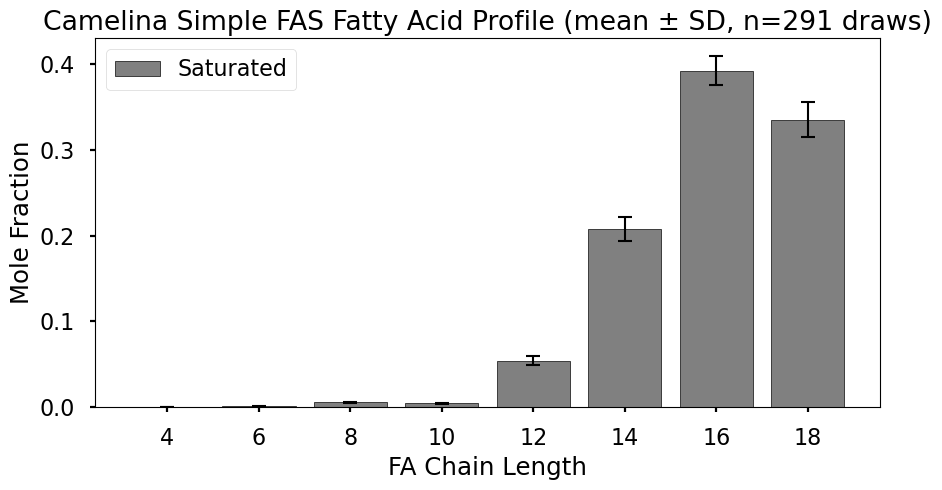

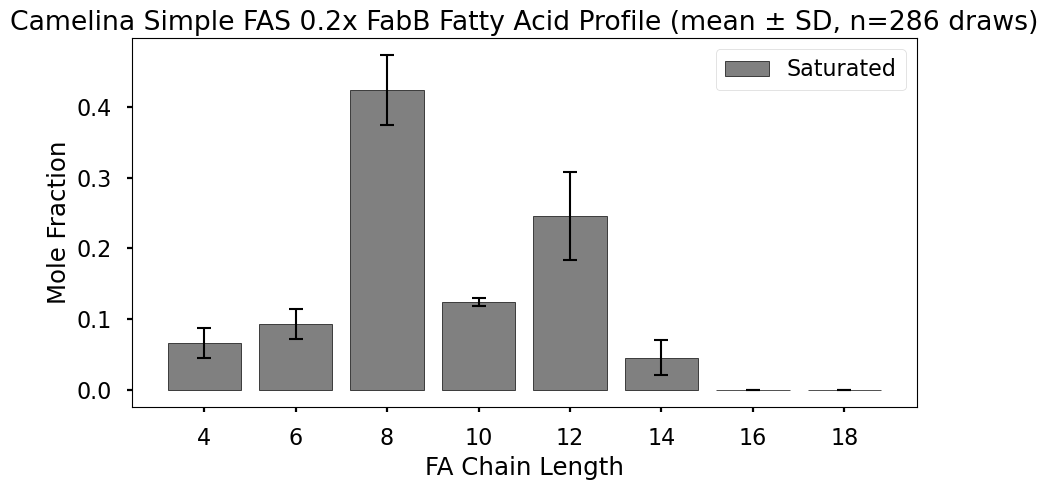

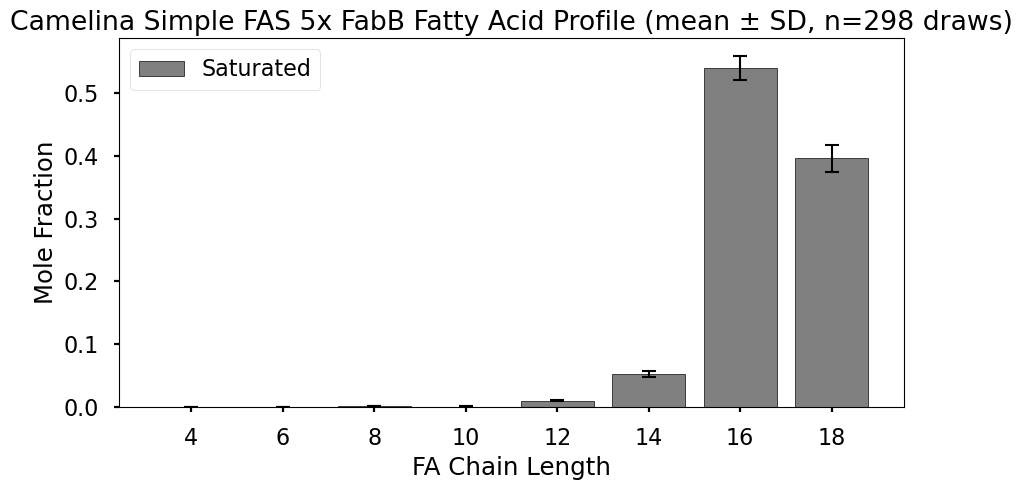

In [55]:
for folder_name in [
    "Camelina Simple FAS",
    "Camelina Simple FAS 0.2x FabB",
    "Camelina Simple FAS 5x FabB",
]:
    plot_fa_profile(folder_name, show_unsaturated=False)